In [3]:
# Set a random seed for reproducibility in TensorFlow
import os
import random
import tensorflow as tf
import numpy as np

def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [4]:
# Load ResLysEmbed model
import tensorflow as tf
from keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Concatenate, Lambda
from keras.models import Model
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy
from keras.initializers import Constant


def residual_block(input_tensor, filters):
    x = Conv1D(filters, kernel_size=3, activation='relu', padding='same')(input_tensor)
    x = Conv1D(filters, kernel_size=3, activation='relu', padding='same')(x)    
    x = Concatenate()([x, input_tensor])  # Skip connection
    return x

def build_resnet_model(input_shape_conv, input_shape_ann):
    # Conv1D branch for sequence data
    conv_input = Input(shape=input_shape_conv)
    x_conv = Embedding(input_dim=21, output_dim=21, name='embedding', trainable=True)(conv_input)

    # Apply Residual blocks
    x_conv = residual_block(x_conv, 32)
    x_conv = MaxPooling1D(pool_size=2)(x_conv)
    x_conv = residual_block(x_conv, 64)
    x_conv = MaxPooling1D(pool_size=2)(x_conv)
    x_conv = Flatten()(x_conv)

    # Dense layer for sequence features
    x_conv = Dense(32, activation='relu')(x_conv)
    x_conv = Dropout(0.3)(x_conv)

    # ANN branch for prot_t5 embeddings
    ann_input = Input(shape=(input_shape_ann,))
    x_ann = Dense(32, activation='relu')(ann_input)
    x_ann = Dropout(0.3)(x_ann)

    # Concatenate Conv1D (ResNet) and ANN branches
    combined = Concatenate()([x_conv, x_ann])

    # Output layer
    x = Dense(32, activation='relu')(combined)
    x = Dropout(0.3)(x)
    output_layer = Dense(1, activation='sigmoid')(x)

    # Build model
    model = Model(inputs=[conv_input, ann_input], outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss=BinaryCrossentropy(),
                  metrics=['accuracy'])

    return model


set_seed(4)

# Define the model with Conv1D input shape (33,) and ANN input shape 1024
ResLysEmbed = build_resnet_model((33,), 1024)

ResLysEmbed.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 33, 21)    │        441 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 33, 32)    │      2,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 33, 32)    │      3,104 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 33, 53)    │          0 │ conv1d_1[0][0],   │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 16, 53)    │          0 │ concatenate[0][0] │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 16, 64)    │     10,240 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 16, 64)    │     12,352 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 117)   │          0 │ conv1d_3[0][0],   │
│ (Concatenate)       │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 8, 117)    │          0 │ concatenate_1[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 936)       │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │     29,984 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │     32,800 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 93,082 (363.60 KB)

 Trainable params: 93,082 (363.60 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Load ResNet branch model
import tensorflow as tf
from tensorflow.keras import layers, models
import shap
import numpy as np
def residual_block(input_tensor, filters):
    x = Conv1D(filters, kernel_size=3, activation='relu', padding='same')(input_tensor)
    x = Conv1D(filters, kernel_size=3, activation='relu', padding='same')(x)    
    x = Concatenate()([x, input_tensor])  # Skip connection
    return x
# Define the Conv branch model separately
def create_conv_branch(input_shape):
    input_layer = layers.Input(shape=input_shape)
    x = layers.Embedding(input_dim=21, output_dim=21)(input_layer)
    x = residual_block(x, 32)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = residual_block(x, 64)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs=input_layer, outputs=x)

# Specify the input shape for your Conv branch
input_shape_conv = (33,)  # Adjust this based on your data
ResNet_branch = create_conv_branch(input_shape_conv)

ResNet_branch.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [6]:
# Load the ANN branch model separately
def create_ann_branch(input_shape):
    input_layer = layers.Input(shape=(input_shape,))
    x = layers.Dense(32, activation='relu')(input_layer)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs=input_layer, outputs=x)

# Specify the input shape for your ANN branch
input_shape_ann = 1024  # Adjust this based on your data
ANN_branch = create_ann_branch(input_shape_ann)
ANN_branch.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [7]:
# Load Train and Test data
import numpy as np
import pandas as pd


# --- Sequence to integer encoding ---
# Create a dictionary to map amino acids to integers
amino_acids = 'ACDEFGHIKLMNPQRSTVWY-'
aa_to_int = {aa: i for i, aa in enumerate(amino_acids)}

# # --- Load and process train data ---
train = pd.read_csv('Train Data/train_t5_pssm.csv')
print(train.shape)

# Remove entries with sequences that contain characters not in the amino_acids set
train = train[train['sequence'].apply(lambda x: all(aa in amino_acids for aa in x))]
print(train.shape)

X_train_embeddings = train['embedding'].apply(lambda x: np.array([float(i) for i in x.strip('[]').split()]))
X_train_embeddings = np.stack(X_train_embeddings.values)
X_train = train['sequence'].values
y_train = train['label'].values
X_train_num = np.array([[aa_to_int[aa] for aa in seq] for seq in X_train])

# Print shapes
print("X_train_embeddings shape:", X_train_embeddings.shape)
print("X_train_num shape:", X_train_num.shape)
print("y_train shape:", y_train.shape)


# --- Load and process test data ---
# test = pd.read_csv('DbPtm/dbptm_benchmark_filtered.csv')
# test = pd.read_csv('PTMGPT2/filtered_succinylation_benchmark_ptmgpt2.csv')
test = pd.read_csv('Test Data/test_t5_pssm.csv')
print(test.shape)

test = test[test['sequence'].apply(lambda x: all(aa in amino_acids for aa in x))]

# X_test_embeddings = test['embedding'].apply(lambda x: np.array([float(i) for i in x.strip('[]').split(',')]))
X_test_embeddings = test['embedding'].apply(lambda x: np.array([float(i) for i in x.strip('[]').split()]))

X_test_embeddings = np.stack(X_test_embeddings.values)
X_test = test['sequence'].values
y_test = test['label'].values

X_test_num = np.array([[aa_to_int[aa] for aa in seq] for seq in X_test])

test = pd.read_csv('DbPtm/dbptm_benchmark_filtered.csv')

test = test[test['sequence'].apply(lambda x: all(aa in amino_acids for aa in x))]

X_test_embeddings_dbptm = test['embedding'].apply(lambda x: np.array([float(i) for i in x.strip('[]').split(',')]))
# X_test_embeddings = test['embedding'].apply(lambda x: np.array([float(i) for i in x.strip('[]').split()]))

X_test_embeddings_dbptm = np.stack(X_test_embeddings_dbptm.values)
X_test_dbptm = test['sequence'].values
y_test_dbptm = test['label'].values

# Convert the sequences to a numerical format and convert to numpy arrays
X_test_num_dbptm = np.array([[aa_to_int[aa] for aa in seq] for seq in X_test_dbptm])

#print shapes
print("X_test_embeddings shape:", X_test_embeddings.shape)
print("X_test_num shape:", X_test_num.shape)
print("y_test shape:", y_test.shape)

print("X_test_embeddings_dbptm shape:", X_test_embeddings_dbptm.shape)
print("X_test_num_dbptm shape:", X_test_num_dbptm.shape)
print("y_test_dbptm shape:", y_test_dbptm.shape)



(8411, 6)
(8411, 6)
X_train_embeddings shape: (8411, 1024)
X_train_num shape: (8411, 33)
y_train shape: (8411,)
(3226, 6)
X_test_embeddings shape: (3226, 1024)
X_test_num shape: (3226, 33)
y_test shape: (3226,)
X_test_embeddings_dbptm shape: (4210, 1024)
X_test_num_dbptm shape: (4210, 33)
y_test_dbptm shape: (4210,)


In [8]:
# Train the ResLysEmbed model and the Branches
ResLysEmbed.load_weights('Models/Weights/res_model.weights.h5')
ResNet_branch.fit(X_train_num, y_train, epochs=40, batch_size=32)
ANN_branch.fit(X_train_embeddings, y_train, epochs=40, batch_size=32)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\saving\saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 36 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Epoch 1/40
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5063 - loss: 0.6932
Epoch 2/40
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5469 - loss: 0.6912
Epoch 3/40
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5967 - loss: 0.6841
Epoch 4/40
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6358 - loss: 0.6478
Epoch 5/40
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6574 - loss: 0.6241
Epoch 6/40
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6813 - loss: 0.6075
Epoch 7/40
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6853 - loss: 0.5977
Epoch 8/40
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6988 - loss: 0.5887
Epoch 9/40
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7064 - loss: 0.5776
Epoch 10/40
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7132 - loss: 0.5703
Epoch 11/40
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7189 - loss: 0.5603
Epoch 12/40
263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [9]:
from sklearn.metrics import matthews_corrcoef, roc_auc_score, average_precision_score, f1_score, confusion_matrix
from matplotlib import pyplot as plt
import numpy as np

def evaluate_metrics(model, X_num, X_emb, y_true):
    # Predict probabilities
    if X_num is not None and X_emb is not None:
        y_pred_prob = model.predict([X_num, X_emb])
    elif X_num is not None:
        y_pred_prob = model.predict(X_num)
    else:
        y_pred_prob = model.predict(X_emb)
    y_pred = (y_pred_prob >= 0.5).astype(int)
    y_pred_prob = y_pred_prob.flatten()  # Flatten to 1D array for metrics
    y_pred = y_pred.flatten()  # Flatten to 1D array for metrics

    print("y_pred_prob shape:", y_pred_prob.shape)
    print("y_pred shape:", y_pred.shape)
    print("y_true shape:", y_true.shape)


    acc = np.mean(y_pred == y_true)
    mcc = matthews_corrcoef(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_prob)
    auprc = average_precision_score(y_true, y_pred_prob)
    f1 = f1_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return [acc, mcc, auc, auprc, specificity, f1]

metrics_names = ['Accuracy', 'MCC', 'AUC', 'AUPRC', 'Specificity', 'F1-score']
model_names = ['ResLysEmbed', 'ResNet Branch', 'MLP Branch']

# Evaluate on original test dataset
results_test = [
    evaluate_metrics(ResLysEmbed, X_test_num, X_test_embeddings, y_test),
    evaluate_metrics(ResNet_branch, X_test_num, None, y_test),
    evaluate_metrics(ANN_branch, None, X_test_embeddings, y_test)
]

# Evaluate on dbptm test dataset
results_dbptm = [
    evaluate_metrics(ResLysEmbed, X_test_num_dbptm, X_test_embeddings_dbptm, y_test_dbptm),
    evaluate_metrics(ResNet_branch, X_test_num_dbptm, None, y_test_dbptm),
    evaluate_metrics(ANN_branch, None, X_test_embeddings_dbptm, y_test_dbptm)
]

results_test = np.array(results_test)
results_dbptm = np.array(results_dbptm)

# Print results
print("\nResults on Original Test Dataset:")
for i, model_name in enumerate(model_names):
    print(f"{model_name}:")
    for j, metric_name in enumerate(metrics_names):
        print(f"  {metric_name}: {results_test[i][j]:.4f}")
print("\nResults on DbPtm Test Dataset:")
for i, model_name in enumerate(model_names):
    print(f"{model_name}:")
    for j, metric_name in enumerate(metrics_names):
        print(f"  {metric_name}: {results_dbptm[i][j]:.4f}")


101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
y_pred_prob shape: (3226,)
y_pred shape: (3226,)
y_true shape: (3226,)
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
y_pred_prob shape: (3226,)
y_pred shape: (3226,)
y_true shape: (3226,)
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step
y_pred_prob shape: (3226,)
y_pred shape: (3226,)
y_true shape: (3226,)
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred_prob shape: (4210,)
y_pred shape: (4210,)
y_true shape: (4210,)
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
y_pred_prob shape: (4210,)
y_pred shape: (4210,)
y_true shape: (4210,)
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step
y_pred_prob shape: (4210,)
y_pred shape: (4210,)
y_true shape: (4210,)

Results on Original Test Dataset:
ResLysEmbed:
  Accuracy: 0.8053
  MCC: 0.3893
  AUC: 0.8733
  AUPRC: 0.3482
  Specificity: 0.8042
  F1-score: 0.3973
ResNet Branch:
  Accuracy: 0.7480
  MCC: 0.2872
  AUC: 0.8254
  AUPRC: 0.2838
  Specificity: 0.7491
  F1-score: 0.3139
MLP Branch:
  Accuracy: 0.7232
  MCC: 0.2611
  AUC: 0

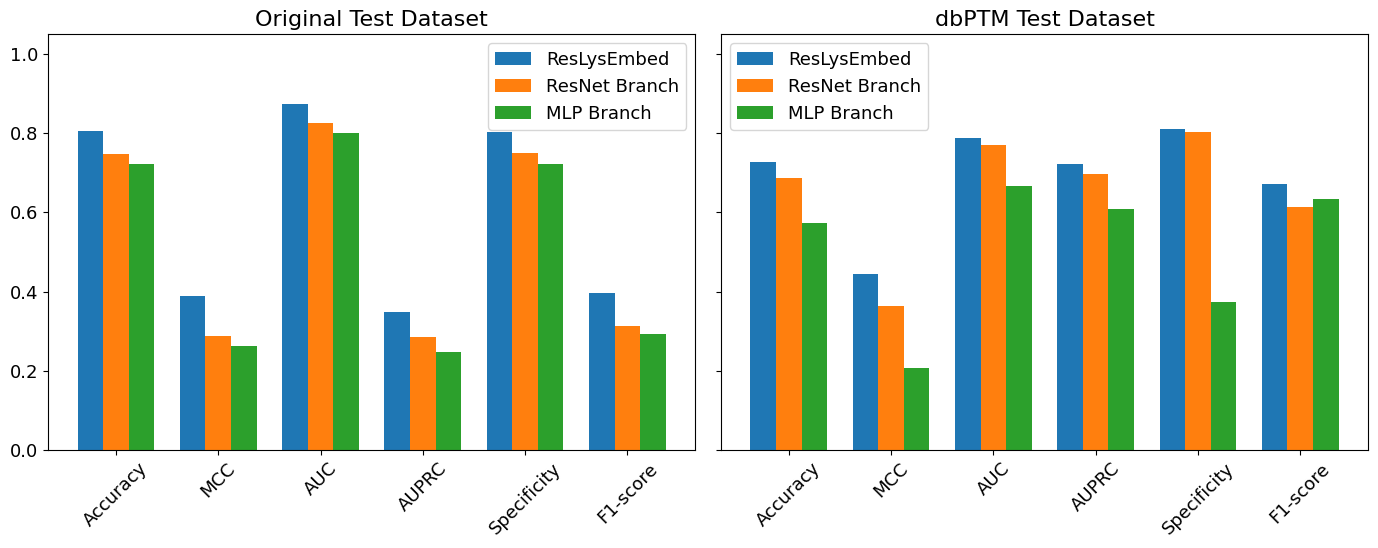

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Increase font size globally
plt.rcParams.update({'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 14, 'xtick.labelsize': 13, 'ytick.labelsize': 13, 'legend.fontsize': 13})

x = np.arange(len(metrics_names))  # the label locations
width = 0.25  # the width of the bars

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Original Test Dataset
axs[0].bar(x - width, results_test[0], width, label=model_names[0])
axs[0].bar(x,         results_test[1], width, label=model_names[1])
axs[0].bar(x + width, results_test[2], width, label=model_names[2])
axs[0].set_title('Original Test Dataset')
axs[0].set_xticks(x)
axs[0].set_xticklabels(metrics_names, rotation=45)
axs[0].set_ylim(0, 1.05)
axs[0].legend()

# DbPtm Test Dataset
axs[1].bar(x - width, results_dbptm[0], width, label=model_names[0])
axs[1].bar(x,         results_dbptm[1], width, label=model_names[1])
axs[1].bar(x + width, results_dbptm[2], width, label=model_names[2])
axs[1].set_title('dbPTM Test Dataset')
axs[1].set_xticks(x)
axs[1].set_xticklabels(metrics_names, rotation=45)
axs[1].set_ylim(0, 1.05)
axs[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('Ablation_study_evaluation_metrics.pdf', format='pdf')
plt.show()
